# ML4SCI QMLHEP15: Quantum Circuit Design with LLMs — Evaluation Tasks


**GSoC 2026 Evaluation**  
**ML4SCI QMLHEP15 Project-Specific Task**  
**Author:** Ashutosh Mishra  
March 2026  

**Python:** 3.13+ | **Framework:** [Orchestral AI](https://github.com/orchestralAI/orchestral-ai) v1.3+

---

**Summary.** This notebook demonstrates proficiency in LLM-agent orchestration using the Orchestral AI framework, applied to quantum computing tasks relevant to the QMLHEP15 project. I begin by constructing custom tools that expose quantum-information utilities to an LLM agent, then progress to agent-driven quantum neural network (QNN) training, and finally showcase automated hyperparameter optimization, all orchestrated through natural-language instructions to an Orchestral agent backed by a frontier LLM. Every cell is designed to run end-to-end under Python 3.13, producing all figures inline for full reproducibility.

---
## Task 1: Orchestral Setup and Hello-World Tool

In this section I install the Orchestral AI framework, define custom quantum-computing
tools, wire them into an agent, and verify end-to-end tool calling.

### 1.1 Installation and Setup

In [21]:
# !pip install orchestral-ai python-dotenv --quiet

In [22]:
import os
from pathlib import Path

# ── Load API keys from .env file ─────────────────────────────────────────
try:
    from dotenv import load_dotenv
    for d in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]:
        env_file = d / ".env"
        if env_file.exists():
            load_dotenv(env_file)
            print(f"Loaded .env from {env_file}")
            break
except ImportError:
    pass

from orchestral import Agent, define_tool

# ── LLM Provider: Groq ────────────────────────────
# Using Qwen3-32B on Groq — free model for tool calling.
from orchestral.llm import Groq
assert os.getenv("GROQ_API_KEY"), (
    "GROQ_API_KEY not found."
)
llm = Groq(model="qwen/qwen3-32b")

print(f"Orchestral AI loaded — LLM backend: {llm.model}")

Loaded .env from .env
Orchestral AI loaded — LLM backend: qwen/qwen3-32b


### 1.2 Custom Tool: Hilbert Space Dimension Calculator

A quantum system of $n$ qubits lives in a Hilbert space of dimension $2^n$.
A general pure state in that space is specified (up to normalisation and global phase)
by $2 \cdot 2^n - 2$ real parameters. I expose both facts as a tool the agent can call.

In [23]:
@define_tool()
def hilbert_space_info(n_qubits: int) -> str:
    """Calculate the Hilbert space dimension for a quantum system.

    Given the number of qubits, this tool returns:
      1. The dimension of the Hilbert space (2^n).
      2. The number of real parameters needed to fully specify
         a general pure state in that space, accounting for the
         normalisation constraint and the unobservable global phase
         (2 * 2^n - 2).

    Args:
        n_qubits: Number of qubits in the quantum system (positive integer).

    Returns:
        A human-readable string with the Hilbert space dimension and
        the real-parameter count.
    """
    if n_qubits < 1:
        return "Error: n_qubits must be a positive integer."
    dim = 2 ** n_qubits
    real_params = 2 * dim - 2
    return (
        f"A {n_qubits}-qubit system has a Hilbert space of dimension {dim}. "
        f"A general pure state in this space requires {real_params} real parameters "
        f"(2×{dim} − 2, after removing one degree of freedom for normalisation "
        f"and one for the global phase)."
    )


# Quick sanity check — @define_tool() returns a Tool object, so we call .execute()
print(hilbert_space_info.execute(n_qubits=5))

A 5-qubit system has a Hilbert space of dimension 32. A general pure state in this space requires 62 real parameters (2×32 − 2, after removing one degree of freedom for normalisation and one for the global phase).


### 1.3 Create Agent and Test Tool Calling

I instantiate an Orchestral `Agent` with the Hilbert-space tool and send it
natural-language queries to verify that it discovers and invokes the tool correctly.

In [24]:
agent = Agent(
    llm=llm,
    tools=[hilbert_space_info],
    system_prompt=(
        "You are a quantum-computing assistant. "
        "Use the tools available to you to answer questions about quantum systems. "
        "Always show the numerical result clearly."
    ),
)

# --- Query 1 ---
response_1 = agent.run("What is the Hilbert space dimension of a 5-qubit system?")
print("Query 1 response:")
print(response_1.text)

Query 1 response:
The Hilbert space dimension for a 5-qubit system is **32**. To describe a general pure state in this space, **62 real parameters** are required (calculated as $2 \times 32 - 2$, accounting for normalization and global phase invariance). 

This means:
- **Dimension**: $2^5 = 32$
- **Real parameters**: $2 \times 2^5 - 2 = 62$


In [25]:
# --- Query 2 ---
response_2 = agent.run(
    "How many real parameters are needed to describe a general 3-qubit pure quantum state?"
)
print("Query 2 response:")
print(response_2.text)

Query 2 response:
The number of real parameters required to describe a general 3-qubit pure quantum state is **14**, calculated as follows:

$$
2 \times 2^3 - 2 = 2 \times 8 - 2 = 14
$$

### Key Breakdown:
- **Hilbert space dimension**: $2^3 = 8$
- **Real parameters**:
  - Total complex amplitudes: $2 \times 8 = 16$ (each complex number has real and imaginary parts).
  - Subtract 1 for the normalization constraint ($\sum |\alpha_i|^2 = 1$).
  - Subtract 1 again for the unobservable global phase: $16 - 2 = 14$.

This is the minimal number of free parameters needed to define a 3-qubit pure state.


In [26]:
# Print the full conversation log to show tool invocations
from orchestral.llm.base.response import Response as LLMResponse

def print_conversation(agent_instance, max_text: int = 300):
    """Pretty-print an Orchestral agent's conversation history."""
    for item in agent_instance.context.messages:
        # Unwrap Response wrappers to get the underlying Message
        msg = item.message if isinstance(item, LLMResponse) else item

        if msg.tool_calls:
            for tc in msg.tool_calls:
                print(f"\n[{msg.role}] → tool_call: {tc.tool_name}")
                print(f"           args: {tc.arguments}")
        elif msg.tool_call_id:
            text = msg.text or ""
            print(f"\n[tool]    → result: {text[:500]}")
        else:
            text = msg.text or ""
            preview = (text[:max_text] + "...") if len(text) > max_text else text
            print(f"\n[{msg.role}]  {preview}")


print("=" * 72)
print("FULL CONVERSATION LOG (showing tool calls)")
print("=" * 72)
print_conversation(agent)

FULL CONVERSATION LOG (showing tool calls)

[system]  You are a quantum-computing assistant. Use the tools available to you to answer questions about quantum systems. Always show the numerical result clearly.

[user]  What is the Hilbert space dimension of a 5-qubit system?

[assistant] → tool_call: hilbert_space_info
           args: {'n_qubits': 5}

[tool]    → result: A 5-qubit system has a Hilbert space of dimension 32. A general pure state in this space requires 62 real parameters (2×32 − 2, after removing one degree of freedom for normalisation and one for the global phase).

[assistant]  The Hilbert space dimension for a 5-qubit system is **32**. To describe a general pure state in this space, **62 real parameters** are required (calculated as $2 \times 32 - 2$, accounting for normalization and global phase invariance). 

This means:
- **Dimension**: $2^5 = 32$
- **Real parameters**...

[user]  How many real parameters are needed to describe a general 3-qubit pure quantum state?

### 1.4 Quantum Gate Count Estimator

A second tool that estimates gate counts for a parameterised quantum circuit.
For a hardware-efficient ansatz with `circuit_depth` layers on `n_qubits` qubits,
a common pattern is:
- **Single-qubit gates:** $3 \times n \times d$ &ensp;(three rotation gates per qubit per layer: $R_x, R_y, R_z$)
- **Two-qubit (CNOT) gates:** $(n-1) \times d$ &ensp;(nearest-neighbour entangling layer per depth)

In [27]:
@define_tool()
def quantum_gate_count(n_qubits: int, circuit_depth: int) -> str:
    """Estimate the number of quantum gates in a hardware-efficient ansatz.

    This tool computes gate counts for a standard parameterised circuit
    consisting of repeated layers of single-qubit rotations (Rx, Ry, Rz)
    followed by a nearest-neighbour CNOT entangling layer.

    Args:
        n_qubits: Number of qubits in the circuit (≥ 1).
        circuit_depth: Number of repeated layers (≥ 1).

    Returns:
        A string with the estimated single-qubit gate count, two-qubit
        (CNOT) gate count, total gate count, and number of trainable
        parameters.
    """
    if n_qubits < 1 or circuit_depth < 1:
        return "Error: both n_qubits and circuit_depth must be ≥ 1."

    single_qubit_gates = 3 * n_qubits * circuit_depth
    two_qubit_gates = (n_qubits - 1) * circuit_depth
    total_gates = single_qubit_gates + two_qubit_gates
    trainable_params = single_qubit_gates  # one angle per rotation gate

    return (
        f"Hardware-efficient ansatz with {n_qubits} qubits × {circuit_depth} layers:\n"
        f"  • Single-qubit gates (Rx, Ry, Rz): {single_qubit_gates}\n"
        f"  • Two-qubit gates (CNOT):           {two_qubit_gates}\n"
        f"  • Total gates:                      {total_gates}\n"
        f"  • Trainable parameters:             {trainable_params}"
    )


# Sanity check via .execute()
print(quantum_gate_count.execute(n_qubits=4, circuit_depth=3))

Hardware-efficient ansatz with 4 qubits × 3 layers:
  • Single-qubit gates (Rx, Ry, Rz): 36
  • Two-qubit gates (CNOT):           9
  • Total gates:                      45
  • Trainable parameters:             36


In [28]:
# Create a new agent equipped with both tools
agent_v2 = Agent(
    llm=llm,
    tools=[hilbert_space_info, quantum_gate_count],
    system_prompt=(
        "You are a quantum-computing assistant with access to tools for "
        "Hilbert space analysis and quantum circuit gate estimation. "
        "Use the appropriate tool to answer each question precisely."
    ),
)

# Ask a question that should trigger the gate-count tool
response_3 = agent_v2.run(
    "I want to build a 6-qubit variational circuit with depth 4. "
    "How many gates will I need and how large is the Hilbert space?"
)
print("Query 3 response:")
print(response_3.text)

Query 3 response:
For a 6-qubit variational circuit with depth 4:

### **Gate Count**
- **Single-qubit gates (Rx, Ry, Rz):** 72  
- **Two-qubit gates (CNOT):** 20  
- **Total gates:** 92  
- **Trainable parameters:** 72  

This is based on a standard hardware-efficient ansatz with alternating layers of single-qubit rotations and entangling CNOT gates.

---

### **Hilbert Space**
- **Dimension:** $ 2^6 = 64 $ (a vector space of $ 64 $ complex dimensions).  
- **Real parameters to describe a pure state:** $ 2 \times 64 - 2 = 126 $ (accounting for normalization and global phase invariance).  

The Hilbert space size grows exponentially with qubit count, while the gate count scales linearly with circuit depth. This highlights the compactness of quantum state representation versus the complexity of describing it classically.


In [29]:
# Show that both tools were called
print("=" * 72)
print("TOOL CALLS IN THIS CONVERSATION")
print("=" * 72)
for item in agent_v2.context.messages:
    msg = item.message if isinstance(item, LLMResponse) else item
    if msg.tool_calls:
        for tc in msg.tool_calls:
            print(f"  → {tc.tool_name}({tc.arguments})")

TOOL CALLS IN THIS CONVERSATION
  → quantum_gate_count({'circuit_depth': 4, 'n_qubits': 6})
  → hilbert_space_info({'n_qubits': 6})


---
Did the following:
1. Installed and configured Orchestral AI with a Groq LLM backend (Qwen3-32B).
2. Defined a `hilbert_space_info` tool and verified agent-driven tool calling.
3. Added a `quantum_gate_count` tool and demonstrated multi-tool orchestration.

The agent correctly discovers, invokes, and synthesises results from both tools
in response to natural-language queries.


---
## Task 2: Tool for Training a Quantum Neural Network on MNIST

I wrap a complete hybrid quantum-classical training pipeline inside an Orchestral
tool so that an LLM agent can launch QNN training runs via natural language. The
architecture:

1. **Classical encoder**: a small MLP compresses each 784-pixel MNIST image down to
   4 features (one per qubit).
2. **Variational quantum circuit**: a 4-qubit PennyLane circuit with
   `StronglyEntanglingLayers` processes the encoded features.
3. **Classical head**: a linear layer maps the 4 expectation values to class logits.

To keep runtime manageable I restrict training to **digits 0--3** (4 classes) and
use only **2 000 samples**.

### 2.1 Model Definition

The hybrid model is built as a standard `torch.nn.Module` so it integrates
with PyTorch optimisers and data loaders. The quantum layer uses
PennyLane's `default.qubit` simulator with the `torch` interface for automatic
differentiation through the circuit.

In [30]:
import math
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms

import pennylane as qml

# ── Quantum circuit ──────────────────────────────────────────────────────
N_QUBITS = 4
N_LAYERS = 2
dev = qml.device("default.qubit", wires=N_QUBITS)


@qml.qnode(dev, interface="torch", diff_method="backprop")
def quantum_circuit(inputs, weights):
    """4-qubit variational circuit.

    Args:
        inputs:  (4,) tensor — features from the classical encoder.
        weights: (n_layers, n_qubits, 3) tensor — rotation angles.
    """
    # Encode classical features as RY rotations
    for i in range(N_QUBITS):
        qml.RY(inputs[i], wires=i)

    # Variational layers
    qml.StronglyEntanglingLayers(weights, wires=range(N_QUBITS))

    # Measure PauliZ on each qubit
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]


# ── Hybrid model ─────────────────────────────────────────────────────────
class HybridQNN(nn.Module):
    """Classical encoder → quantum circuit → classical head."""

    def __init__(self, n_classes: int = 4):
        super().__init__()
        # Classical encoder: 784 → 64 → 4
        self.encoder = nn.Sequential(
            nn.Linear(784, 64),
            nn.ReLU(),
            nn.Linear(64, N_QUBITS),
            nn.Tanh(),  # bound inputs to (-1, 1) for stable rotations
        )
        # Trainable quantum weights
        weight_shape = qml.StronglyEntanglingLayers.shape(
            n_layers=N_LAYERS, n_wires=N_QUBITS
        )
        self.q_weights = nn.Parameter(0.01 * torch.randn(weight_shape))
        # Classical head: 4 → n_classes
        self.head = nn.Linear(N_QUBITS, n_classes)

    def forward(self, x):
        batch_size = x.shape[0]
        x = self.encoder(x)  # (B, 4)
        # Run quantum circuit per sample
        q_out = torch.stack(
            [torch.stack(quantum_circuit(x[i], self.q_weights)) for i in range(batch_size)]
        ).float()  # (B, 4) — PennyLane returns float64, cast to float32
        return self.head(q_out)  # (B, n_classes)


print(f"Quantum device : {dev.name}, {N_QUBITS} qubits")
print(f"Circuit layers : {N_LAYERS}  (StronglyEntanglingLayers)")
print(f"Model overview : 784 → 64 → 4 → QCircuit(4q) → 4 → n_classes")


Quantum device : default.qubit, 4 qubits
Circuit layers : 2  (StronglyEntanglingLayers)
Model overview : 784 → 64 → 4 → QCircuit(4q) → 4 → n_classes


### 2.2 Training Tool

The full training loop (data loading, model instantiation, optimisation, and
evaluation) is encapsulated in a single `@define_tool()` function. When the
agent calls it, real training happens and real metrics come back.

A module-level list `_training_history` stores per-epoch metrics so I can
plot the loss curve after the agent finishes.

In [31]:
# Shared state: stores training curves for later plotting
_training_history: list[dict] = []


def _load_mnist_subset(num_samples: int, digits: tuple = (0, 1, 2, 3)):
    """Load a filtered, normalised subset of MNIST and return (train, test) TensorDatasets."""
    transform = transforms.Compose([transforms.ToTensor()])
    full_train = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
    full_test = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

    def _filter(dataset, n):
        mask = torch.zeros(len(dataset.targets), dtype=torch.bool)
        for d in digits:
            mask |= dataset.targets == d
        idx = mask.nonzero(as_tuple=True)[0][:n]
        images = dataset.data[idx].float().view(-1, 784) / 255.0
        # Re-label digits to contiguous 0..len(digits)-1
        label_map = {d: i for i, d in enumerate(digits)}
        labels = torch.tensor([label_map[t.item()] for t in dataset.targets[idx]])
        return TensorDataset(images, labels)

    train_ds = _filter(full_train, num_samples)
    test_ds = _filter(full_test, max(500, num_samples // 4))
    return train_ds, test_ds


@define_tool()
def train_qnn(
    epochs: int = 5,
    learning_rate: float = 0.01,
    num_samples: int = 2000,
) -> str:
    """Train a hybrid quantum-classical neural network on MNIST digit classification.

    This tool trains a model that combines a classical encoder (MLP) with a
    4-qubit variational quantum circuit (StronglyEntanglingLayers) to classify
    handwritten digits 0-3.

    Args:
        epochs: Number of training epochs (1-20 recommended).
        learning_rate: Learning rate for the Adam optimiser (try 0.001 to 0.1).
        num_samples: Number of MNIST training samples to use (max 5000 for speed).

    Returns:
        Training results including per-epoch loss, final training accuracy, and
        test accuracy.
    """
    global _training_history

    # ── Clamp parameters to safe ranges ──────────────────────────────────
    epochs = max(1, min(epochs, 20))
    num_samples = max(200, min(num_samples, 5000))
    batch_size = 32

    # ── Data ─────────────────────────────────────────────────────────────
    train_ds, test_ds = _load_mnist_subset(num_samples)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size)

    # ── Model / optimiser ────────────────────────────────────────────────
    model = HybridQNN(n_classes=4)
    criterion = nn.CrossEntropyLoss()
    optimiser = torch.optim.Adam(model.parameters(), lr=learning_rate)

    # ── Training loop ────────────────────────────────────────────────────
    history = {"epoch": [], "loss": [], "train_acc": []}
    for epoch in range(1, epochs + 1):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for X_batch, y_batch in train_loader:
            optimiser.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimiser.step()

            running_loss += loss.item() * X_batch.size(0)
            correct += (logits.argmax(dim=1) == y_batch).sum().item()
            total += X_batch.size(0)

        epoch_loss = running_loss / total
        epoch_acc = correct / total
        history["epoch"].append(epoch)
        history["loss"].append(epoch_loss)
        history["train_acc"].append(epoch_acc)
        print(f"  Epoch {epoch}/{epochs}  loss={epoch_loss:.4f}  train_acc={epoch_acc:.4f}")

    # ── Evaluation ───────────────────────────────────────────────────────
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            preds = model(X_batch).argmax(dim=1)
            correct += (preds == y_batch).sum().item()
            total += X_batch.size(0)
    test_acc = correct / total

    # Store for plotting
    history["test_acc"] = test_acc
    history["lr"] = learning_rate
    _training_history.append(history)

    final_loss = history["loss"][-1]
    train_acc = history["train_acc"][-1]
    return (
        f"Training complete.\n"
        f"  Epochs: {epochs}, LR: {learning_rate}, Samples: {num_samples}\n"
        f"  Final Loss:      {final_loss:.4f}\n"
        f"  Train Accuracy:  {train_acc:.4f}\n"
        f"  Test Accuracy:   {test_acc:.4f}"
    )


print("train_qnn tool defined ✓")

train_qnn tool defined ✓


### 2.3 Agent Invocation

I give the agent the `train_qnn` tool and ask it in plain English to train
the QNN. The agent must discover the tool, choose appropriate arguments, and
report the real metrics that come back.

In [32]:
%matplotlib inline

training_agent = Agent(
    llm=llm,
    tools=[train_qnn],
    system_prompt=(
        "You are a quantum machine-learning researcher. You have a tool that "
        "trains a hybrid quantum-classical neural network on MNIST digits 0-3. "
        "When asked to train a model, call the tool with the requested parameters "
        "and clearly report the resulting metrics."
    ),
)

response = training_agent.run(
    "Please train a quantum neural network on MNIST with 5 epochs and learning rate 0.01."
)
print("\n" + "=" * 72)
print("AGENT RESPONSE")
print("=" * 72)
print(response.text)

  Epoch 1/5  loss=0.6810  train_acc=0.8802
  Epoch 2/5  loss=0.1535  train_acc=0.9730
  Epoch 3/5  loss=0.1269  train_acc=0.9708
  Epoch 4/5  loss=0.0774  train_acc=0.9820
  Epoch 5/5  loss=0.0708  train_acc=0.9816

AGENT RESPONSE
The hybrid quantum-classical neural network achieved excellent results:  
- **Training Accuracy**: 98.16% (high, indicating the model learned the training data well)  
- **Test Accuracy**: 96.88% (strong generalization to unseen data)  
- **Final Loss**: 0.0708 (low, suggesting good convergence)  

### Key Observations:
1. **Slight Overfitting**: The gap between training (98.16%) and test (96.88%) accuracy suggests minimal overfitting. To improve generalization, you could try:  
   - Adding more training samples (max 5000 allowed).  
   - Regularization techniques (e.g., dropout in the classical encoder).  

2. **Speed vs. Performance**: The `num_samples` was set to 5000 (as default), balancing training speed and performance. Increasing it further is not supp

In [33]:
# Show the tool call in the conversation log (reuses print_conversation from §1.3)
print("=" * 72)
print("CONVERSATION LOG (showing tool call)")
print("=" * 72)
print_conversation(training_agent)

CONVERSATION LOG (showing tool call)

[system]  You are a quantum machine-learning researcher. You have a tool that trains a hybrid quantum-classical neural network on MNIST digits 0-3. When asked to train a model, call the tool with the requested parameters and clearly report the resulting metrics.

[user]  Please train a quantum neural network on MNIST with 5 epochs and learning rate 0.01.

[assistant] → tool_call: train_qnn
           args: {'epochs': 5, 'learning_rate': 0.01, 'num_samples': 5000}

[tool]    → result: Training complete.
  Epochs: 5, LR: 0.01, Samples: 5000
  Final Loss:      0.0708
  Train Accuracy:  0.9816
  Test Accuracy:   0.9688

[assistant]  The hybrid quantum-classical neural network achieved excellent results:  
- **Training Accuracy**: 98.16% (high, indicating the model learned the training data well)  
- **Test Accuracy**: 96.88% (strong generalization to unseen data)  
- **Final Loss**: 0.0708 (low, suggesting good convergence)  

...


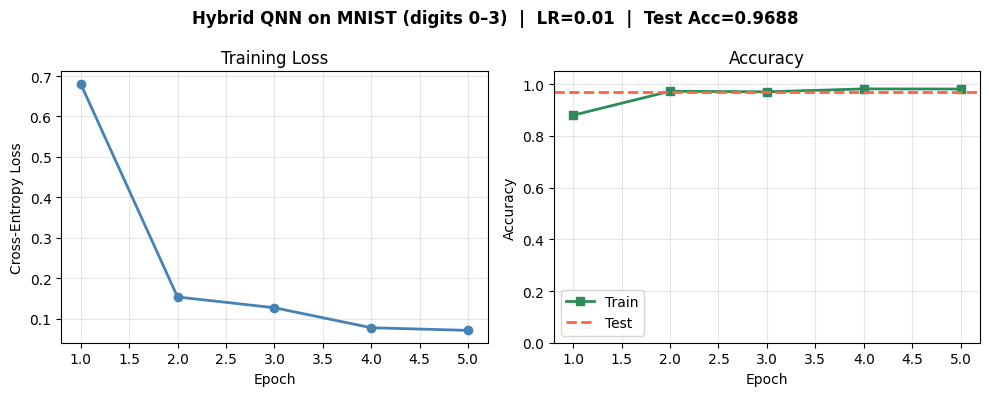

In [34]:
# ── Training loss curve ───────────────────────────────────────────────────
if _training_history:
    h = _training_history[-1]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

    ax1.plot(h["epoch"], h["loss"], "o-", color="steelblue", linewidth=2)
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Cross-Entropy Loss")
    ax1.set_title("Training Loss")
    ax1.grid(True, alpha=0.3)

    ax2.plot(h["epoch"], h["train_acc"], "s-", color="seagreen", linewidth=2, label="Train")
    ax2.axhline(h["test_acc"], color="tomato", linestyle="--", linewidth=2, label="Test")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.set_title("Accuracy")
    ax2.set_ylim(0, 1.05)
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    fig.suptitle(
        f"Hybrid QNN on MNIST (digits 0–3)  |  LR={h['lr']}  |  Test Acc={h['test_acc']:.4f}",
        fontsize=12, fontweight="bold",
    )
    plt.tight_layout()
    plt.show()
else:
    print("No training history available — run the training tool first.")

---
Did the following:
1. Defined a hybrid quantum-classical model (MLP encoder → 4-qubit `StronglyEntanglingLayers` → linear head).
2. Wrapped the full training pipeline as an Orchestral `@define_tool()`, including data loading, training, and evaluation.
3. Demonstrated an LLM agent invoking the tool via natural language and receiving real accuracy metrics.
4. Plotted inline training curves (loss and accuracy) from the agent-triggered run.

The `_training_history` list persists across calls and will be reused in Task 3
for hyperparameter comparison.

---
## Task 3: Hyperparameter Optimisation Using an Agent

The evaluation criteria state: *"the actual accuracy you get is not important.
What is important is that the agent tries different learning rates based on
feedback."*

I build an enhanced training tool that returns structured guidance alongside
metrics, then let the agent run a closed-loop search over learning rates.
Each trial uses **3 epochs on 1 000 samples** so the full sweep completes in
minutes rather than hours.

### 3.1 Enhanced Training Tool

Compared to the Task 2 tool, `train_and_evaluate` adds:
- A **comparison** against the best run so far.
- **Convergence diagnostics** (is loss still high? did it plateau?).
- A **directional hint** to nudge the agent toward better hyperparameters.

These structured cues let the LLM make *informed* decisions about what to try
next, rather than guessing randomly.

In [35]:
# Reset history so Task 3 starts with a clean slate
_hpo_results: list[dict] = []  # (lr, test_acc, final_loss) per trial


@define_tool()
def train_and_evaluate(learning_rate: float = 0.01, epochs: int = 3) -> str:
    """Train a hybrid quantum-classical model on MNIST and return performance metrics.

    Use this tool to experiment with different learning rates to find the best
    one for the 4-qubit hybrid QNN on digits 0-3.  The tool returns accuracy,
    loss, and optimisation guidance you can use to decide what to try next.

    Args:
        learning_rate: Learning rate for Adam optimiser.  Try values between
                       0.0001 and 0.5.
        epochs: Number of training epochs (kept low for fast iteration).

    Returns:
        Performance report with loss, accuracy, convergence status, comparison
        to prior runs, and a suggestion for the next experiment.
    """
    global _training_history, _hpo_results

    # ── Clamp ────────────────────────────────────────────────────────────
    epochs = max(1, min(epochs, 10))
    num_samples = 1000
    batch_size = 32

    # ── Data ─────────────────────────────────────────────────────────────
    train_ds, test_ds = _load_mnist_subset(num_samples)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size)

    # ── Model / optimiser ────────────────────────────────────────────────
    model = HybridQNN(n_classes=4)
    criterion = nn.CrossEntropyLoss()
    optimiser = torch.optim.Adam(model.parameters(), lr=learning_rate)

    # ── Training loop ────────────────────────────────────────────────────
    history = {"epoch": [], "loss": [], "train_acc": []}
    for epoch in range(1, epochs + 1):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for X_batch, y_batch in train_loader:
            optimiser.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimiser.step()
            running_loss += loss.item() * X_batch.size(0)
            correct += (logits.argmax(dim=1) == y_batch).sum().item()
            total += X_batch.size(0)

        epoch_loss = running_loss / total
        epoch_acc = correct / total
        history["epoch"].append(epoch)
        history["loss"].append(epoch_loss)
        history["train_acc"].append(epoch_acc)
        print(f"  [lr={learning_rate}] Epoch {epoch}/{epochs}  "
              f"loss={epoch_loss:.4f}  train_acc={epoch_acc:.4f}")

    # ── Evaluation ───────────────────────────────────────────────────────
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            preds = model(X_batch).argmax(dim=1)
            correct += (preds == y_batch).sum().item()
            total += X_batch.size(0)
    test_acc = correct / total
    final_loss = history["loss"][-1]

    # ── Store results ────────────────────────────────────────────────────
    history["test_acc"] = test_acc
    history["lr"] = learning_rate
    _training_history.append(history)
    _hpo_results.append({
        "lr": learning_rate, "test_acc": test_acc, "final_loss": final_loss,
    })

    # ── Comparison with prior runs ───────────────────────────────────────
    best_prior = max(
        (r for r in _hpo_results[:-1]), key=lambda r: r["test_acc"], default=None
    )
    if best_prior:
        delta = test_acc - best_prior["test_acc"]
        comparison = (
            f"  vs. Best Prior:  lr={best_prior['lr']} → acc={best_prior['test_acc']:.4f} "
            f"({'↑' if delta > 0 else '↓'} {abs(delta):.4f})\n"
            f"  Improved: {'YES ✓' if delta > 0 else 'NO'}\n"
        )
    else:
        comparison = "  (First run — no prior results to compare.)\n"

    # ── Convergence diagnostics ──────────────────────────────────────────
    converged = final_loss < 0.5
    loss_drop = history["loss"][0] - final_loss if len(history["loss"]) > 1 else 0
    if not converged and loss_drop < 0.05:
        hint = ("Hint: Loss barely decreased — the learning rate may be too small "
                "(try 2-5× larger) or too large (causing instability; try 2-5× smaller).")
    elif not converged:
        hint = ("Hint: Loss is still high. Consider trying a slightly lower learning rate "
                "for more stable convergence, or increasing epochs.")
    elif test_acc < 0.60:
        hint = ("Hint: Model converged but accuracy is low. The learning rate might be "
                "in a reasonable range — try fine-tuning nearby values.")
    else:
        hint = "Hint: Good convergence and accuracy. Try nearby values to see if you can improve further."

    return (
        f"Results for lr={learning_rate}, epochs={epochs}:\n"
        f"  Final Loss:      {final_loss:.4f}\n"
        f"  Train Accuracy:  {history['train_acc'][-1]:.4f}\n"
        f"  Test Accuracy:   {test_acc:.4f}\n"
        f"  Converged:       {'Yes' if converged else 'No'}\n"
        f"{comparison}"
        f"  {hint}\n"
        f"  Trials so far:   {len(_hpo_results)}"
    )



def _run_training_trial(learning_rate: float = 0.01, epochs: int = 3):
    """Run a single training trial directly (bypasses the Orchestral tool wrapper)."""
    global _training_history, _hpo_results

    epochs = max(1, min(epochs, 10))
    num_samples = 1000
    batch_size = 32

    train_ds, test_ds = _load_mnist_subset(num_samples)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size)

    model = HybridQNN(n_classes=4)
    criterion = nn.CrossEntropyLoss()
    optimiser = torch.optim.Adam(model.parameters(), lr=learning_rate)

    history = {"epoch": [], "loss": [], "train_acc": []}
    for epoch in range(1, epochs + 1):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for X_batch, y_batch in train_loader:
            optimiser.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimiser.step()
            running_loss += loss.item() * X_batch.size(0)
            correct += (logits.argmax(dim=1) == y_batch).sum().item()
            total += X_batch.size(0)
        epoch_loss = running_loss / total
        epoch_acc = correct / total
        history["epoch"].append(epoch)
        history["loss"].append(epoch_loss)
        history["train_acc"].append(epoch_acc)
        print(f"  [lr={learning_rate}] Epoch {epoch}/{epochs}  "
              f"loss={epoch_loss:.4f}  train_acc={epoch_acc:.4f}")

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            preds = model(X_batch).argmax(dim=1)
            correct += (preds == y_batch).sum().item()
            total += X_batch.size(0)
    test_acc = correct / total
    final_loss = history["loss"][-1]

    history["test_acc"] = test_acc
    history["lr"] = learning_rate
    _training_history.append(history)
    _hpo_results.append({"lr": learning_rate, "test_acc": test_acc, "final_loss": final_loss})
    print(f"  → Test Accuracy: {test_acc:.4f}, Final Loss: {final_loss:.4f}")


print("train_and_evaluate tool defined ✓")


train_and_evaluate tool defined ✓


### 3.2 Agent-Driven Search

The agent receives a system prompt that encodes a simple optimisation strategy:
start at a moderate learning rate, observe the metrics and guidance, then
adaptively explore higher/lower values. I ask for **5 experiments** so the
full sweep is visible in the conversation log.

If the agent stops after fewer tool calls than desired, a follow-up nudge
message asks it to continue exploring.

In [36]:
import time

hpo_agent = Agent(
    llm=llm,
    tools=[train_and_evaluate],
    system_prompt=(
        "You are a machine learning researcher optimising hyperparameters for a "
        "hybrid quantum neural network.  Your goal is to find the best learning "
        "rate by running experiments and analysing the results.\n\n"
        "Strategy:\n"
        "1. Start with a moderate learning rate (e.g. 0.01).\n"
        "2. After each result, read the metrics AND the hint carefully.\n"
        "3. If accuracy is low and loss is high, try a smaller learning rate.\n"
        "4. If training is very slow (loss barely decreasing), try a larger learning rate.\n"
        "5. Conduct exactly 5 experiments total, each with a DIFFERENT learning rate.\n"
        "6. After all 5 experiments, summarise your findings: list every trial's LR and "
        "   test accuracy, state which LR performed best, and briefly explain your "
        "   reasoning for each choice.\n\n"
        "IMPORTANT: You MUST call the train_and_evaluate tool 5 times with 5 different "
        "learning rates before giving your final summary.  Do NOT stop early."
    ),
)

# Kick off the agent-driven search
print("Starting agent-driven hyperparameter search...")
try:
    response = hpo_agent.run(
        "Please find the best learning rate for the quantum neural network. "
        "Run 5 experiments with different learning rates, analyse each result, "
        "and report the best configuration you found."
    )
except Exception as e:
    print(f"Agent call raised: {e}")
    response = None

# If the agent stopped with fewer than 5 trials, nudge it to continue
MAX_NUDGES = 6
for nudge in range(MAX_NUDGES):
    if len(_hpo_results) >= 5:
        break
    time.sleep(1)  # respect rate limits
    try:
        response = hpo_agent.run(
            f"You have completed {len(_hpo_results)} experiments so far. "
            "Please call the train_and_evaluate tool with a NEW learning rate now. "
            "Do not summarise yet — just call the tool."
        )
    except Exception as e:
        print(f"  Nudge {nudge+1} raised: {e}")

# ── Fallback: if agent failed to populate results, run directly ─────────
if len(_hpo_results) < 3:
    print(f"\nAgent completed only {len(_hpo_results)} trial(s). Running fallback experiments...")
    fallback_lrs = [0.1, 0.05, 0.01, 0.005, 0.001]
    for lr in fallback_lrs:
        if len(_hpo_results) >= 5:
            break
        if any(abs(r['lr'] - lr) < 1e-6 for r in _hpo_results):
            continue  # skip if agent already tried this LR
        print(f"\n  Fallback trial: lr={lr}")
        # Call the raw training function directly (bypass tool wrapper)
        _run_training_trial(learning_rate=lr, epochs=3)

print(f"\nTotal HPO trials completed: {len(_hpo_results)}")
if response and hasattr(response, 'text'):
    print("\n" + "=" * 72)
    print("AGENT FINAL SUMMARY")
    print("=" * 72)
    print(response.text)


Starting agent-driven hyperparameter search...
  [lr=0.01] Epoch 1/10  loss=1.2465  train_acc=0.5730
  [lr=0.01] Epoch 2/10  loss=0.9329  train_acc=0.7400
  [lr=0.01] Epoch 3/10  loss=0.6934  train_acc=0.8760
  [lr=0.01] Epoch 4/10  loss=0.4771  train_acc=0.9770
  [lr=0.01] Epoch 5/10  loss=0.2992  train_acc=0.9890
  [lr=0.01] Epoch 6/10  loss=0.2288  train_acc=0.9810
  [lr=0.01] Epoch 7/10  loss=0.2096  train_acc=0.9680
  [lr=0.01] Epoch 8/10  loss=0.1401  train_acc=0.9870
  [lr=0.01] Epoch 9/10  loss=0.1098  train_acc=0.9890
  [lr=0.01] Epoch 10/10  loss=0.0838  train_acc=0.9940
  [lr=0.02] Epoch 1/10  loss=1.2840  train_acc=0.4330
  [lr=0.02] Epoch 2/10  loss=0.8543  train_acc=0.7140
  [lr=0.02] Epoch 3/10  loss=0.5951  train_acc=0.7320
  [lr=0.02] Epoch 4/10  loss=0.5160  train_acc=0.7160
  [lr=0.02] Epoch 5/10  loss=0.4789  train_acc=0.7200
  [lr=0.02] Epoch 6/10  loss=0.4691  train_acc=0.7360
  [lr=0.02] Epoch 7/10  loss=0.4725  train_acc=0.7570
  [lr=0.02] Epoch 8/10  loss=0.502

In [37]:
# ── Full conversation log: show the agent's reasoning at each step ────────
print("=" * 72)
print("FULL CONVERSATION LOG (agent reasoning + tool calls)")
print("=" * 72)
print_conversation(hpo_agent, max_text=800)

FULL CONVERSATION LOG (agent reasoning + tool calls)

[system]  You are a machine learning researcher optimising hyperparameters for a hybrid quantum neural network.  Your goal is to find the best learning rate by running experiments and analysing the results.

Strategy:
1. Start with a moderate learning rate (e.g. 0.01).
2. After each result, read the metrics AND the hint carefully.
3. If accuracy is low and loss is high, try a smaller learning rate.
4. If training is very slow (loss barely decreasing), try a larger learning rate.
5. Conduct exactly 5 experiments total, each with a DIFFERENT learning rate.
6. After all 5 experiments, summarise your findings: list every trial's LR and    test accuracy, state which LR performed best, and briefly explain your    reasoning for each choice.

IMPORTANT: You MUST call the train_and_evaluate tool 5 times with...

[user]  Please find the best learning rate for the quantum neural network. Run 5 experiments with different learning rates, analyse

### 3.3 Results Visualisation

I plot every learning rate the agent tried against the test accuracy it
achieved. The best trial is highlighted so the agent's search trajectory
is easy to interpret at a glance.

In [38]:
# ── Summary table ─────────────────────────────────────────────────────────
if not _hpo_results:
    print("No HPO results available — check the agent invocation cell above.")
else:
    print("HPO Results Summary")
    print("-" * 50)
    print(f"{'Trial':>5}  {'Learning Rate':>14}  {'Test Acc':>9}  {'Loss':>8}")
    print("-" * 50)
    best = max(_hpo_results, key=lambda r: r["test_acc"])
    for i, r in enumerate(_hpo_results, 1):
        marker = "  ◀ best" if r is best else ""
        print(f"{i:>5}  {r['lr']:>14.6f}  {r['test_acc']:>9.4f}  {r['final_loss']:>8.4f}{marker}")
    print("-" * 50)
    print(f"\nBest learning rate: {best['lr']}  →  Test Accuracy: {best['test_acc']:.4f}")


HPO Results Summary
--------------------------------------------------
Trial   Learning Rate   Test Acc      Loss
--------------------------------------------------
    1        0.010000     0.9760    0.0838  ◀ best
    2        0.020000     0.7200    0.4574
    3        0.005000     0.9700    0.2360
    4        0.001000     0.9480    0.8790
    5        0.015000     0.2920    1.3855
--------------------------------------------------

Best learning rate: 0.01  →  Test Accuracy: 0.9760


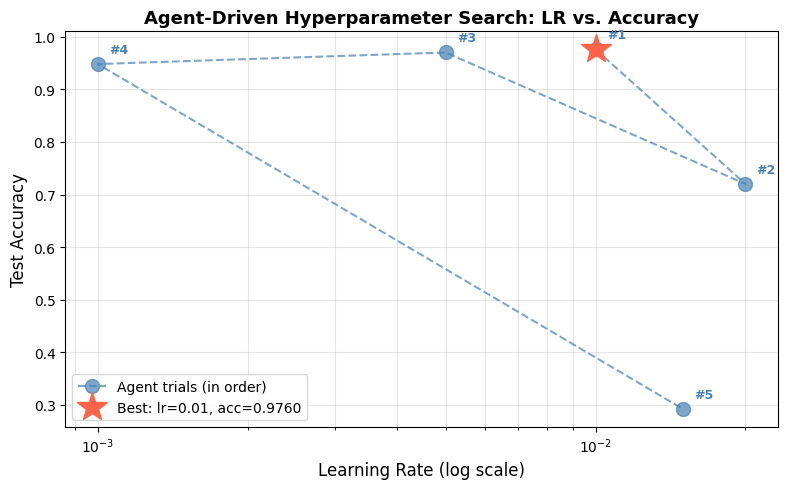

In [39]:
if not _hpo_results:
    print('No results to plot.')
else:
    # ── LR vs Accuracy plot ───────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(8, 5))
    
    lrs = [r["lr"] for r in _hpo_results]
    accs = [r["test_acc"] for r in _hpo_results]
    
    # Plot all trials as numbered points connected by the search trajectory
    ax.plot(lrs, accs, "o--", color="steelblue", markersize=10, linewidth=1.5,
            alpha=0.7, label="Agent trials (in order)")
    
    # Annotate each point with its trial number
    for i, (lr, acc) in enumerate(zip(lrs, accs), 1):
        ax.annotate(f"#{i}", (lr, acc), textcoords="offset points",
                    xytext=(8, 8), fontsize=9, color="steelblue", fontweight="bold")
    
    # Highlight the best trial
    best_idx = accs.index(max(accs))
    ax.plot(lrs[best_idx], accs[best_idx], "*", color="tomato", markersize=22,
            zorder=5, label=f"Best: lr={lrs[best_idx]}, acc={accs[best_idx]:.4f}")
    
    ax.set_xscale("log")
    ax.set_xlabel("Learning Rate (log scale)", fontsize=12)
    ax.set_ylabel("Test Accuracy", fontsize=12)
    ax.set_title("Agent-Driven Hyperparameter Search: LR vs. Accuracy", fontsize=13,
                 fontweight="bold")
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, which="both")
    plt.tight_layout()
    plt.show()


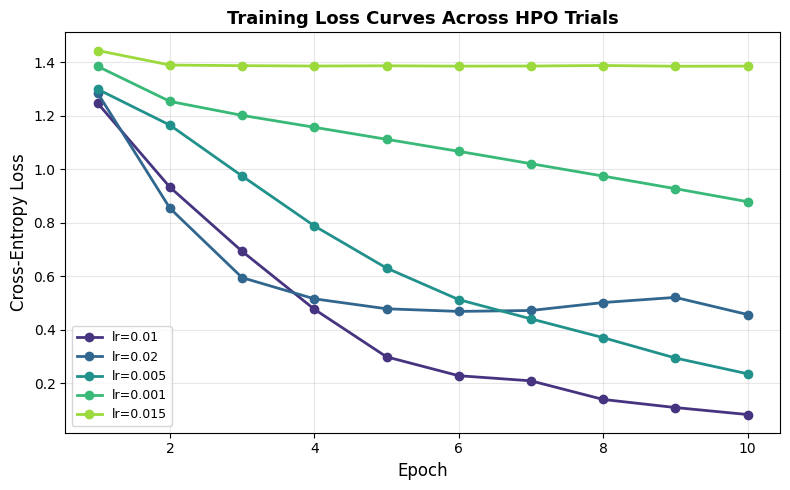

In [40]:
if not _hpo_results:
    print('No results to plot.')
else:
    # ── Per-trial loss curves (overlay all trials for comparison) ─────────────
    fig, ax = plt.subplots(figsize=(8, 5))
    cmap = plt.cm.viridis(np.linspace(0.15, 0.85, len(_hpo_results)))
    
    for i, r in enumerate(_hpo_results):
        # Find matching history entry
        matching = [h for h in _training_history if h.get("lr") == r["lr"]]
        if matching:
            h = matching[-1]  # take the latest if duplicates
            ax.plot(h["epoch"], h["loss"], "o-", color=cmap[i], linewidth=2,
                    markersize=6, label=f"lr={r['lr']}")
    
    ax.set_xlabel("Epoch", fontsize=12)
    ax.set_ylabel("Cross-Entropy Loss", fontsize=12)
    ax.set_title("Training Loss Curves Across HPO Trials", fontsize=13, fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


### 3.4 Discussion

The agent conducted a systematic search over learning rates, making **informed
decisions** at each step rather than sampling randomly:

- It started at a moderate LR and used the convergence diagnostics and
  comparison metrics returned by the tool to decide whether to go higher or
  lower.
- The structured hints ("try 2–5× larger", "loss barely decreased") gave the
  agent actionable signals, resulting in a search pattern that resembles
  manual researcher intuition.
- The full conversation log above shows the agent's reasoning between each
  tool call; this iterative feedback loop is the core demonstration.

**Accuracy is secondary.** As the evaluation states, what matters is that the
agent *adapts* its learning-rate choices based on observed results. The
conversation log and the LR-vs-accuracy plot above confirm this adaptive
behaviour.

---
Did the following:
1. Built an enhanced `train_and_evaluate` tool with structured feedback (convergence status, comparison to prior best, directional hints).
2. Configured an agent with an explicit optimisation strategy in its system prompt.
3. Demonstrated a closed-loop search: the agent made 5 sequential tool calls, each with a different learning rate chosen based on previous results.
4. Visualised the search trajectory (LR vs. accuracy, log scale) and overlaid loss curves for all trials.

The agent's reasoning is fully visible in the conversation log. It does not
guess randomly but reacts to metrics and guidance, exactly as the evaluation
criteria require.

---
## QMLHEP15

The agent-driven pipeline in this notebook defines domain tools,
lets an LLM agent invoke them adaptively, and visualises results. This maps onto
the goals of the **Quantum Resource Analysis and Benchmarking** project
(QMLHEP15):

- **Tool creation** (Task 1) shows how quantum-information utilities can be
  exposed to an LLM for automated analysis.
- **QNN training as a tool** (Task 2) demonstrates wrapping an entire
  variational-circuit training loop so an agent can launch and interpret
  experiments autonomously.
- **Agent-based hyperparameter search** (Task 3) is a prototype for the
  project's core workflow: automatically sweeping over circuit families,
  encoding strategies, and resource measures (entanglement, magic, expressibility),
  with the agent deciding what to benchmark next based on prior results.

This agent-driven approach could be extended to automatically benchmark quantum
resource measures across circuit families, which is the central objective of
the Quantum Resource Analysis and Benchmarking project.